# Vizualization Notebook
## Letterboxd Dashboard
### Reid B.

# Import & Load 

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

ratings = pd.read_csv("data/ratings.csv")
diary = pd.read_csv("data/diary.csv")
watched = pd.read_csv("data/watched.csv")
watchlist = pd.read_csv("data/watchlist.csv")

for df in [ratings, diary, watched, watchlist]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    if 'year' in df.columns:
        df['year'] = df['year'].astype('Int64')

diary['watched_date'] = pd.to_datetime(diary['watched_date'], errors='coerce')
diary['date']         = pd.to_datetime(diary['date'], errors='coerce')
diary_dated           = diary.dropna(subset=['watched_date'])
ratings['decade']     = (ratings['year'] // 10 * 10).astype(str) + 's'

# Rating Distribution

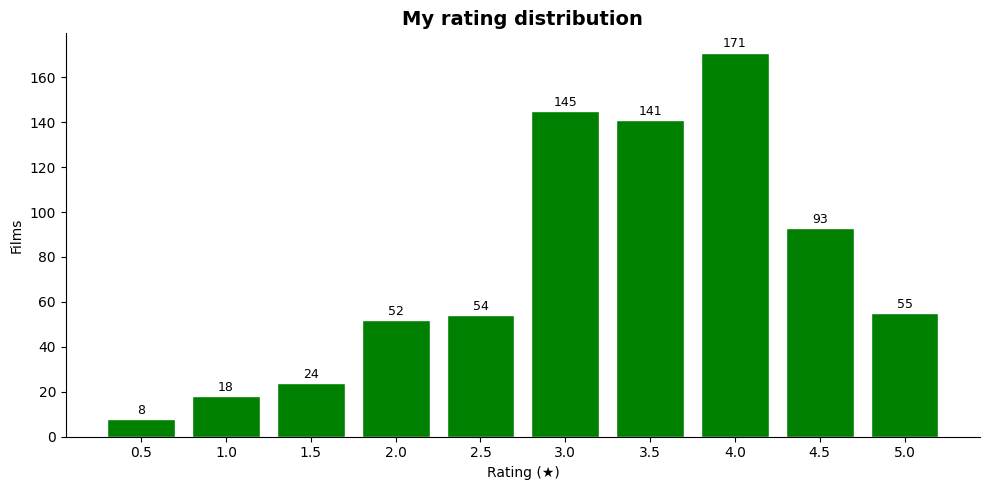

In [22]:
rc = ratings['rating'].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(rc.index.astype(str), rc.values, color='green', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('My rating distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating (★)')
ax.set_ylabel('Films')
plt.tight_layout()
plt.show()

# Header stats (All-time)

## Films Watched

In [23]:
# films watched 
films_watched = len(watched)
print(f'Films watched: {films_watched}')

Films watched: 1230


## Longest Streak

In [40]:
# streak (days)
watch_dates = (
    diary.watched_date.dt.date.drop_duplicates().sort_values().reset_index(drop=True)
)

longest_streak = 1
current_streak = 1

for i in range(1, len(watch_dates)):
    gap = (watch_dates[i] - watch_dates[i - 1]).days
    if gap == 1:
        current_streak += 1
        longest_streak = max(longest_streak, current_streak)
    else:
        current_streak = 1

print(f'Longest streak: {longest_streak} consecutive days')

# Streak (weeks)
watch_weeks = (
    diary['watched_date'].dt.to_period('W').drop_duplicates().sort_values().reset_index(drop=True)
)

longest_week_streak = 1
current_week_streak = 1

for i in range(1, len(watch_weeks)):
    gap = watch_weeks[i].week - watch_weeks[i - 1].week
    year_gap = watch_weeks[i].year - watch_weeks[i - 1].year
    
    is_consecutive = (gap == 1) or (year_gap == 1 and gap < 0)
    
    if is_consecutive:
        current_week_streak += 1
        longest_week_streak = max(longest_week_streak, current_week_streak)
    else:
        current_week_streak = 1

print(f'Longest weekly streak: {longest_week_streak} consecutive weeks')

Longest streak: 20 consecutive days
Longest weekly streak: 33 consecutive weeks


## Multi-film Days

In [41]:
films_per_day = diary.groupby(diary['watched_date'].dt.date)['name'].count()
multi_film_days = (films_per_day >= 2).sum()

print(f'Multi-film days: {multi_film_days}')

Multi-film days: 192


# Top films

## By Year - Films


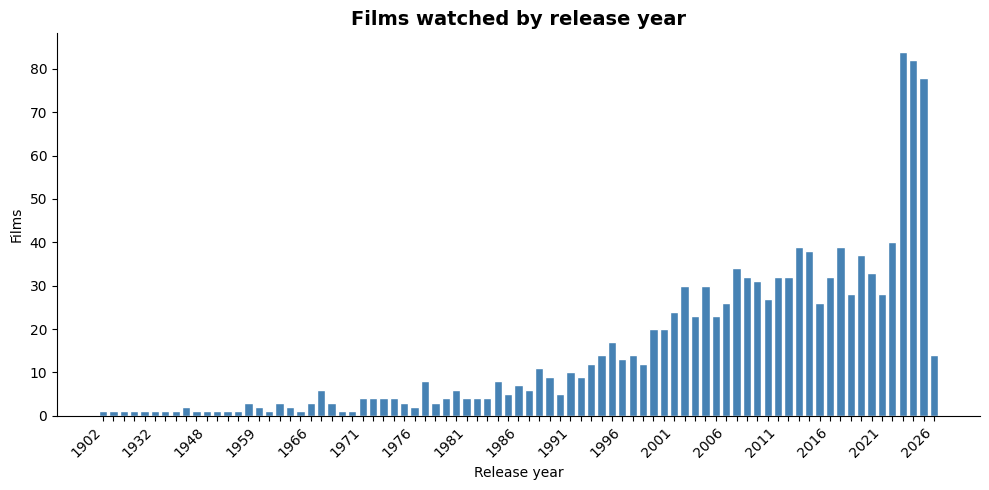

In [48]:
# by year
year_counts = watched['year'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(year_counts.index.astype(str), year_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Films watched by release year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release year')
ax.set_ylabel('Films')

plt.xticks(rotation=45, ha='right')
#show every 5th label to avoid crowding
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

## By Year - Ratings

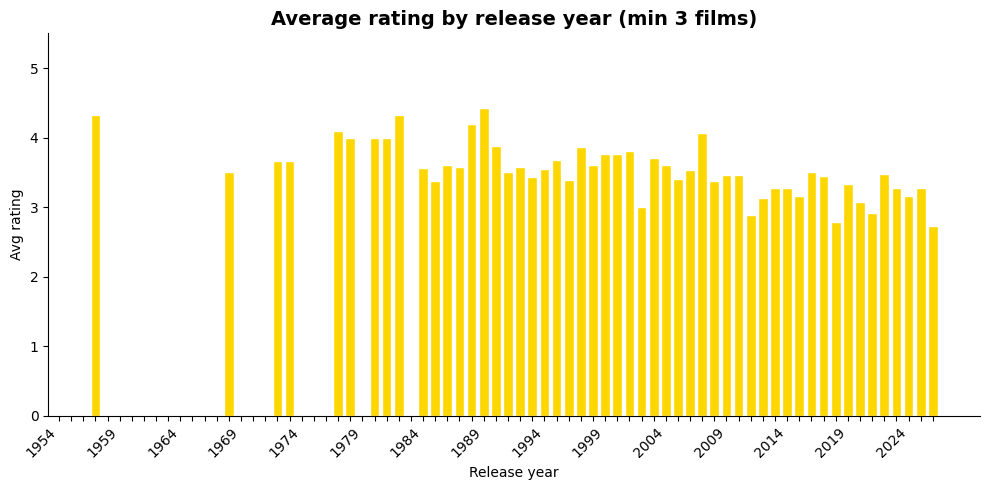

In [64]:
# avg rating by year (min 3 films)
ratings_year = (
    ratings.groupby('year')['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_rating', 'count': 'films'})
    .sort_values('year')
)

# fill in missing years with NaN
full_range = pd.RangeIndex(ratings_year['year'].min(), ratings_year['year'].max() + 1)
ratings_year = ratings_year.set_index('year').reindex(full_range).reset_index()
ratings_year.columns = ['year', 'avg_rating', 'films']

# mask years with fewer than 3 films
ratings_year.loc[ratings_year['films'] < 3, 'avg_rating'] = float('nan')

fig, ax = plt.subplots()
ax.bar(ratings_year['year'].astype(str), ratings_year['avg_rating'].round(2),
       color='gold', edgecolor='white')

ax.set_title('Average rating by release year (min 3 films)', fontsize=14, fontweight='bold')
ax.set_xlabel('Release year')
ax.set_ylabel('Avg rating')
ax.set_ylim(0, 5.5)

plt.xticks(rotation=45, ha='right')
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

## By Year - Diary

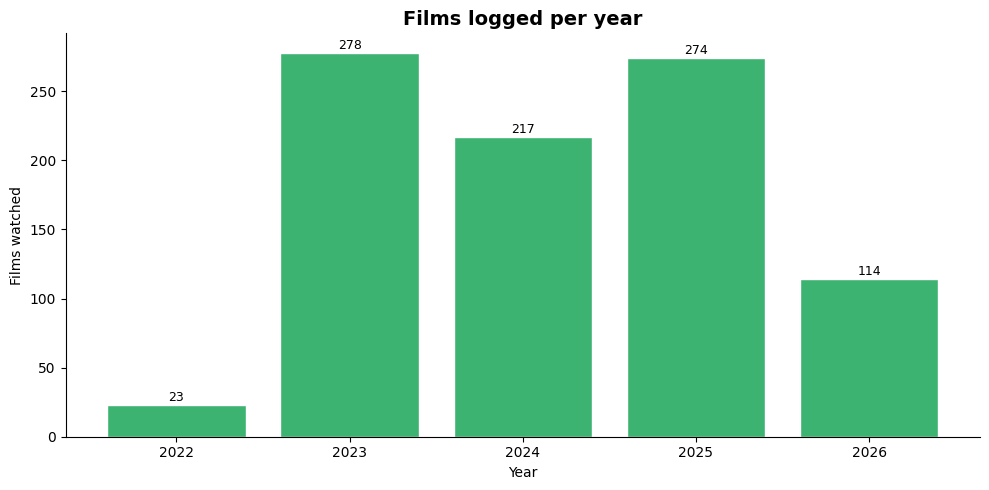

In [75]:
fig, ax = plt.subplots()
bars = ax.bar(diary_year.index.astype(str), diary_year.values,
              color='mediumseagreen', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Films logged per year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Films watched')
plt.tight_layout()
plt.show()

# Highest rated decades

In [85]:
# by decade
ratings['decade'] = (ratings['year'] // 10 * 10).astype(str) + 's'
decade_ct = ratings.groupby("decade")["rating"].count().sort_values(ascending=False)
decade_avg = round(ratings.groupby("decade")["rating"].mean().sort_values(ascending=False), 2)

# Filter to decades with at least 20 films
min_films = 20
decade_ct = decade_ct[decade_ct >= min_films]
decade_avg = decade_avg[decade_avg.index.isin(decade_ct.index)]

#print(decade_ct.head())
print(decade_avg.head())

decade
1970s    3.94
1980s    3.86
2000s    3.62
1990s    3.62
2010s    3.26
Name: rating, dtype: float64


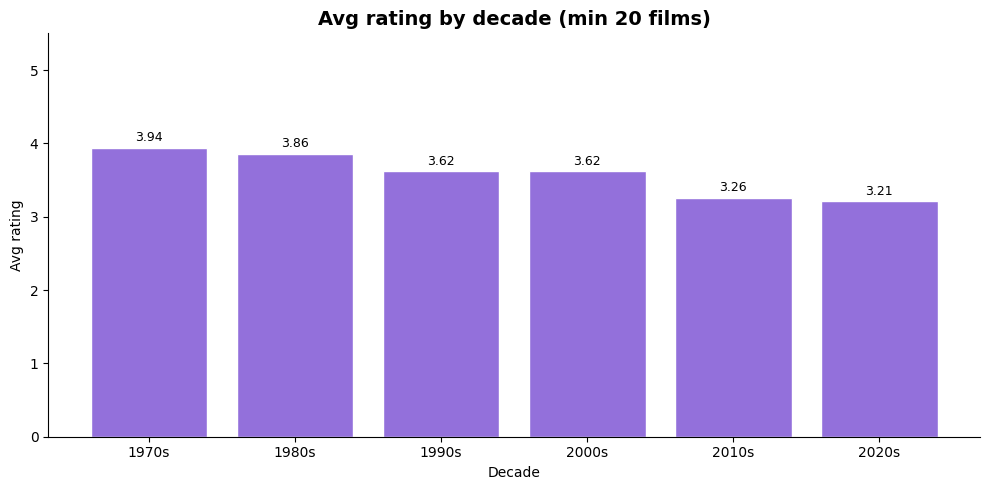

In [87]:
decade_stats = (
    ratings.groupby('decade')['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_rating', 'count': 'films'})
    .query('films >= 20')
    .sort_values('decade')
)

fig, ax = plt.subplots()
bars = ax.bar(decade_stats['decade'], decade_stats['avg_rating'].round(2),
              color='mediumpurple', edgecolor='white')

for bar, val in zip(bars, decade_stats['avg_rating']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Avg rating by decade (min 20 films)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Avg rating')
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

## Most Watched

name
Scott Pilgrim vs. the World              8
Frances Ha                               6
Mulholland Drive                         4
Superman                                 4
Past Lives                               4
Blue Velvet                              4
Lady Bird                                4
Fargo                                    3
Rudolph the Red-Nosed Reindeer           3
The Perks of Being a Wallflower          3
Scott Pilgrim Takes Off                  3
Dune                                     3
Princess Mononoke                        3
The Wind Rises                           3
Hot Rod                                  3
Die Hard                                 3
National Lampoon's Christmas Vacation    3
Spirited Away                            3
Planes, Trains and Automobiles           3
The Worst Person in the World            3
dtype: int64

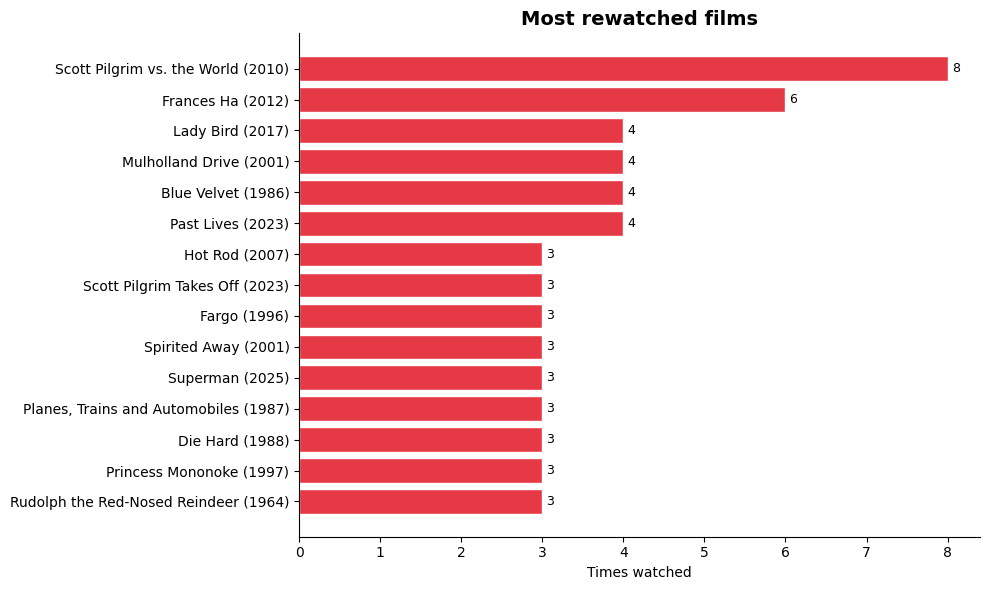

In [93]:
#diary.groupby('name').size().sort_values(ascending=False).head(20)

rewatched = (
    diary.groupby(['name', 'year'])
    .size()
    .reset_index(name='watches')
    .query('watches > 1')
    .sort_values('watches')
    .tail(15)
)
rewatched['label'] = rewatched['name'] + ' (' + rewatched['year'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(rewatched['label'], rewatched['watches'], color='#e63946', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        str(int(bar.get_width())),
        va='center', fontsize=9
    )

ax.set_title('Most rewatched films', fontsize=14, fontweight='bold')
ax.set_xlabel('Times watched')
plt.tight_layout()
plt.show()

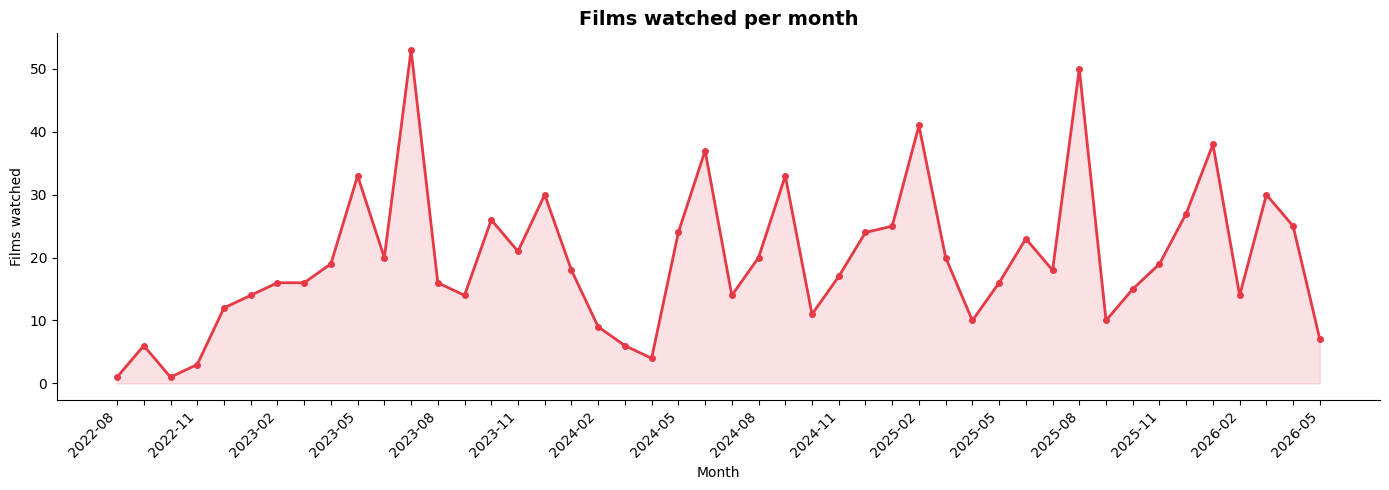

In [94]:
monthly = (
    diary_dated
    .groupby(diary_dated['watched_date'].dt.to_period('M'))
    .size()
    .reset_index(name='films')
)
monthly['watched_date'] = monthly['watched_date'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['watched_date'], monthly['films'],
        color='#e63946', linewidth=2, marker='o', markersize=4)
ax.fill_between(range(len(monthly)), monthly['films'], alpha=0.15, color='#e63946')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['watched_date'], rotation=45, ha='right')
# show every 3rd label
for i, label in enumerate(ax.get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)
ax.set_title('Films watched per month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Films watched')
plt.tight_layout()
plt.show()

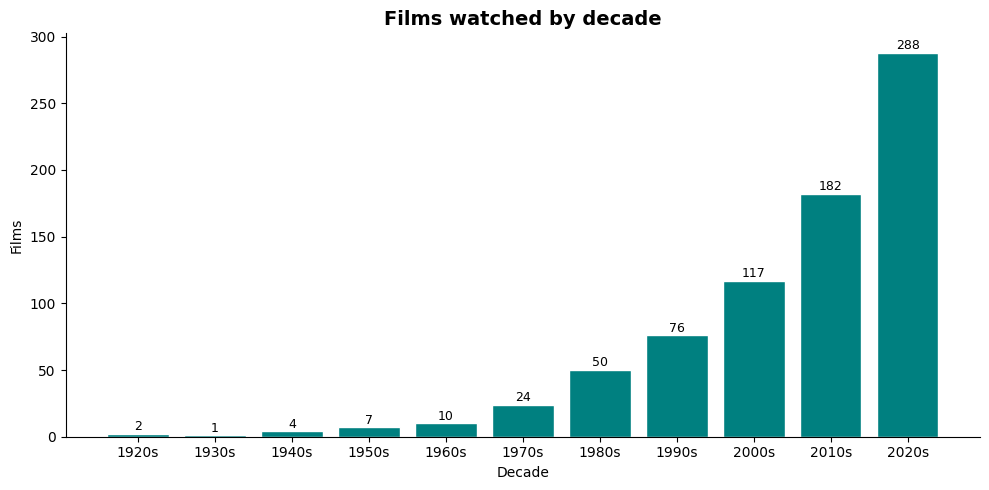

In [96]:
decade_counts = ratings['decade'].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(decade_counts.index, decade_counts.values, color='teal', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Films watched by decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Films')
plt.tight_layout()
plt.show()

## TBD for API
genres, countries, & languages
themes
list progress
collections

top cast
most watched, highest rated

top directors
most watched, highest rated

crew & studios
most watched, highest rated

world map

# New Analysis

# Viewing Habits

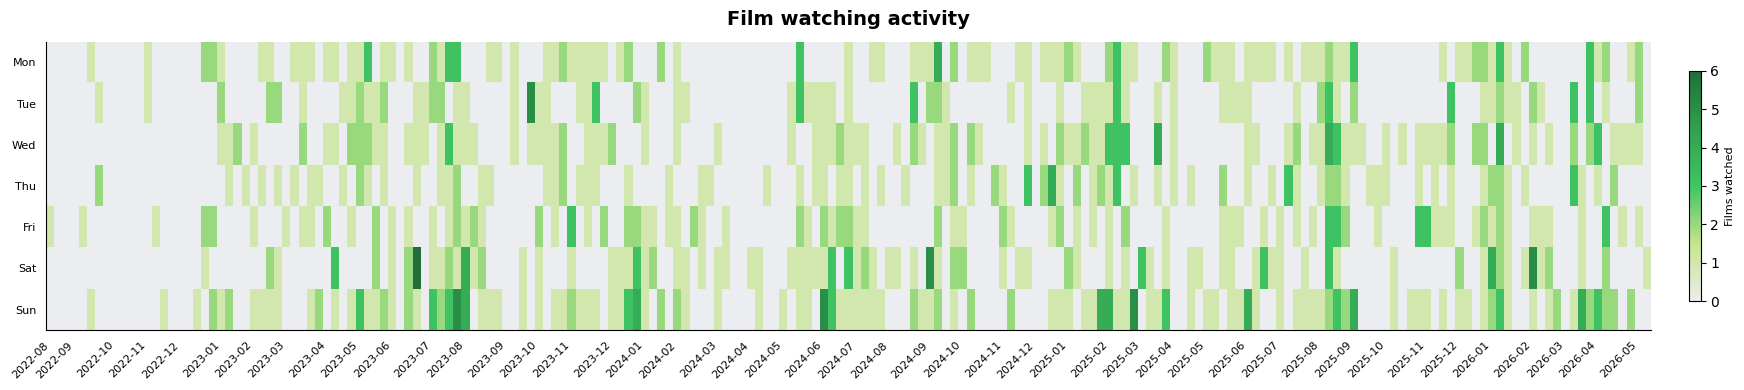

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# count films per day
films_per_day = (
    diary_dated.groupby(diary_dated['watched_date'].dt.date)['name']
    .count()
    .reset_index()
)
films_per_day.columns = ['date', 'count']
films_per_day['date'] = pd.to_datetime(films_per_day['date'])

# build full date range from first to last watch
date_range = pd.date_range(films_per_day['date'].min(), films_per_day['date'].max())
all_days = pd.DataFrame({'date': date_range})
all_days = all_days.merge(films_per_day, on='date', how='left').fillna(0)
all_days['count'] = all_days['count'].astype(int)

# get day of week (0=Mon, 6=Sun) and week number
all_days['dow'] = all_days['date'].dt.dayofweek
all_days['week'] = (all_days['date'] - all_days['date'].min()).dt.days // 7

# build 2D grid: rows = days of week, cols = weeks
num_weeks = all_days['week'].max() + 1
grid = np.zeros((7, num_weeks))
for _, row in all_days.iterrows():
    grid[int(row['dow']), int(row['week'])] = row['count']

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(20, 4))

# custom colormap: light grey for 0, green shades for 1+
cmap = mcolors.LinearSegmentedColormap.from_list(
    'github', ['#ebedf0', '#c6e48b', '#40c463', '#30a14e', '#216e39']
)

im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=0, vmax=max(3, grid.max()))

# y axis — days of week
ax.set_yticks(range(7))
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=8)

# x axis — month labels
months = all_days.groupby(all_days['date'].dt.to_period('M'))['week'].min()
ax.set_xticks(months.values)
ax.set_xticklabels([str(m) for m in months.index], rotation=45, ha='right', fontsize=8)

ax.set_title('Film watching activity', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(left=False, bottom=False)

# colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label('Films watched', fontsize=8)

plt.tight_layout()
plt.show()

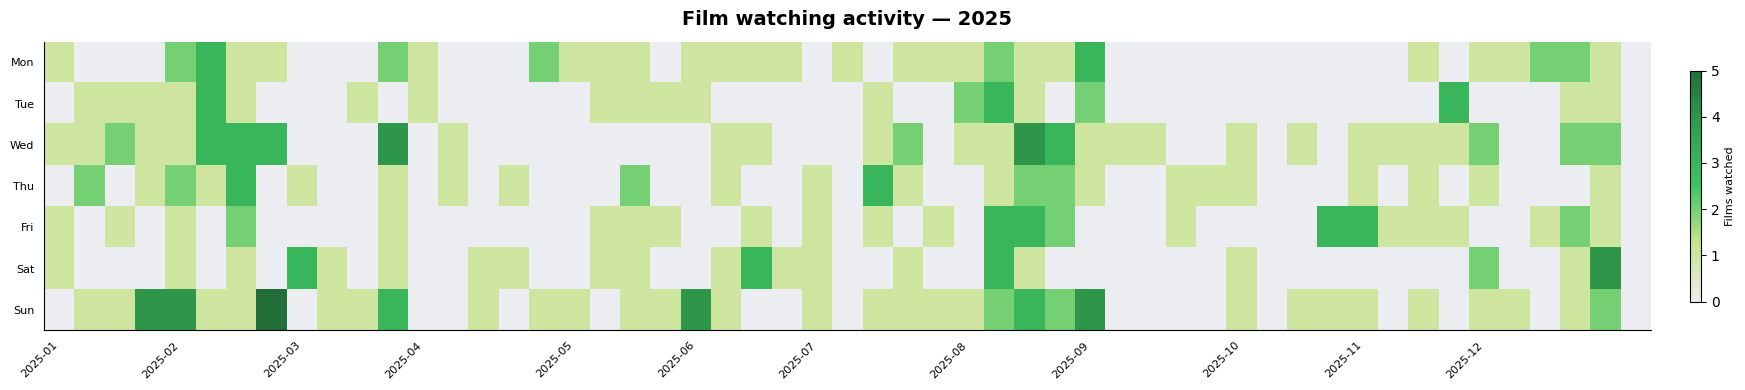

In [101]:
# filter to 2025
diary_2025 = diary_dated[diary_dated['watched_date'].dt.year == 2025]

# count films per day
films_per_day = (
    diary_2025.groupby(diary_2025['watched_date'].dt.date)['name']
    .count()
    .reset_index()
)
films_per_day.columns = ['date', 'count']
films_per_day['date'] = pd.to_datetime(films_per_day['date'])

# build full 2025 date range
date_range = pd.date_range('2025-01-01', '2025-12-31')
all_days = pd.DataFrame({'date': date_range})
all_days = all_days.merge(films_per_day, on='date', how='left').fillna(0)
all_days['count'] = all_days['count'].astype(int)
all_days['dow'] = all_days['date'].dt.dayofweek
all_days['week'] = (all_days['date'] - all_days['date'].min()).dt.days // 7

# build grid
num_weeks = all_days['week'].max() + 1
grid = np.zeros((7, num_weeks))
for _, row in all_days.iterrows():
    grid[int(row['dow']), int(row['week'])] = row['count']

# plot
fig, ax = plt.subplots(figsize=(20, 4))
cmap = mcolors.LinearSegmentedColormap.from_list(
    'github', ['#ebedf0', '#c6e48b', '#40c463', '#30a14e', '#216e39']
)
im = ax.imshow(grid, cmap=cmap, aspect='auto', vmin=0, vmax=max(3, grid.max()))

ax.set_yticks(range(7))
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], fontsize=8)

months = all_days.groupby(all_days['date'].dt.to_period('M'))['week'].min()
ax.set_xticks(months.values)
ax.set_xticklabels([str(m) for m in months.index], rotation=45, ha='right', fontsize=8)

ax.set_title('Film watching activity — 2025', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(left=False, bottom=False)

cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label('Films watched', fontsize=8)

plt.tight_layout()
plt.show()

## Avg rating by month

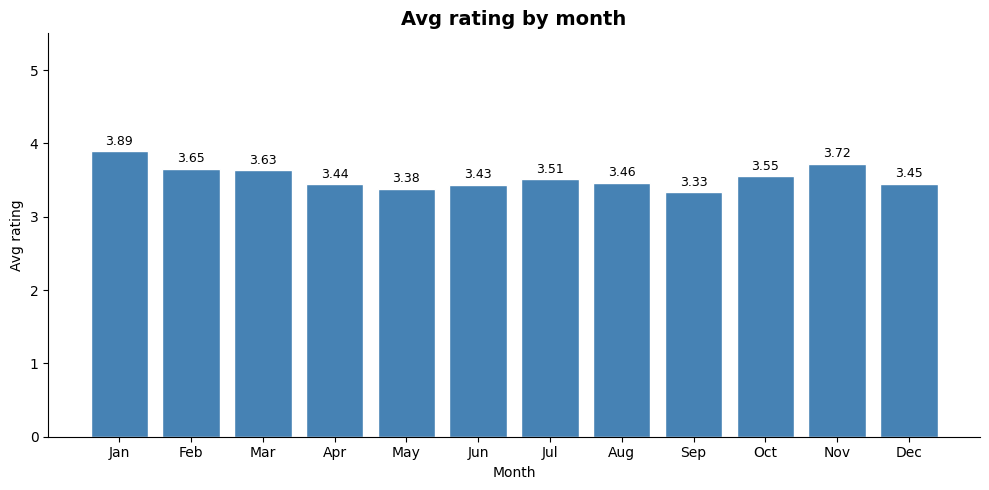

In [102]:
month_ratings = (
    diary_dated.dropna(subset=['rating'])
    .groupby(diary_dated['watched_date'].dt.month)['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'watched_date': 'month', 'mean': 'avg_rating', 'count': 'films'})
    .query('films >= 3')
)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_ratings['month_name'] = month_ratings['month'].apply(lambda x: month_names[x - 1])

fig, ax = plt.subplots()
bars = ax.bar(month_ratings['month_name'], month_ratings['avg_rating'].round(2),
              color='steelblue', edgecolor='white')

for bar, val in zip(bars, month_ratings['avg_rating']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Avg rating by month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg rating')
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

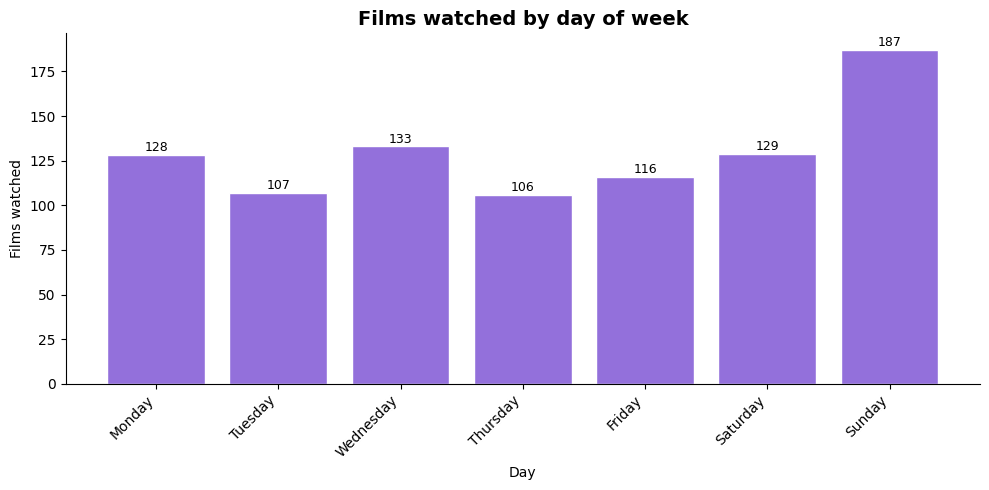

In [103]:
day_counts = (
    diary_dated
    .groupby(diary_dated['watched_date'].dt.day_name())['name']
    .count()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

fig, ax = plt.subplots()
bars = ax.bar(day_counts.index, day_counts.values, color='mediumpurple', edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Films watched by day of week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Films watched')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Rating Analysis

## Rating over time

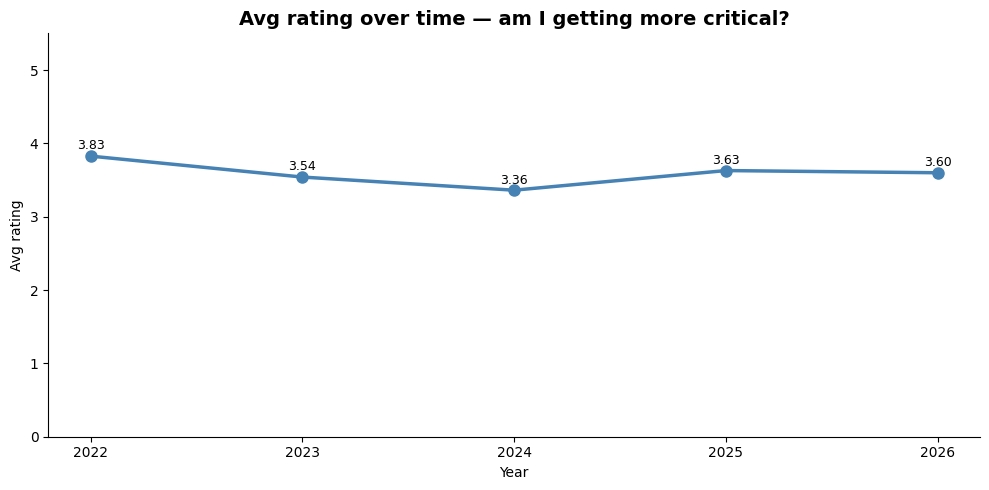

In [104]:
rating_over_time = (
    diary_dated.dropna(subset=['rating'])
    .groupby(diary_dated['watched_date'].dt.year)['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'watched_date': 'year', 'mean': 'avg_rating', 'count': 'films'})
    .query('films >= 10')
)

fig, ax = plt.subplots()
ax.plot(rating_over_time['year'], rating_over_time['avg_rating'],
        color='steelblue', linewidth=2.5, marker='o', markersize=8)

for _, row in rating_over_time.iterrows():
    ax.text(row['year'], row['avg_rating'] + 0.05, f"{row['avg_rating']:.2f}",
            ha='center', va='bottom', fontsize=9)

ax.set_title('Avg rating over time — am I getting more critical?', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg rating')
ax.set_ylim(0, 5.5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

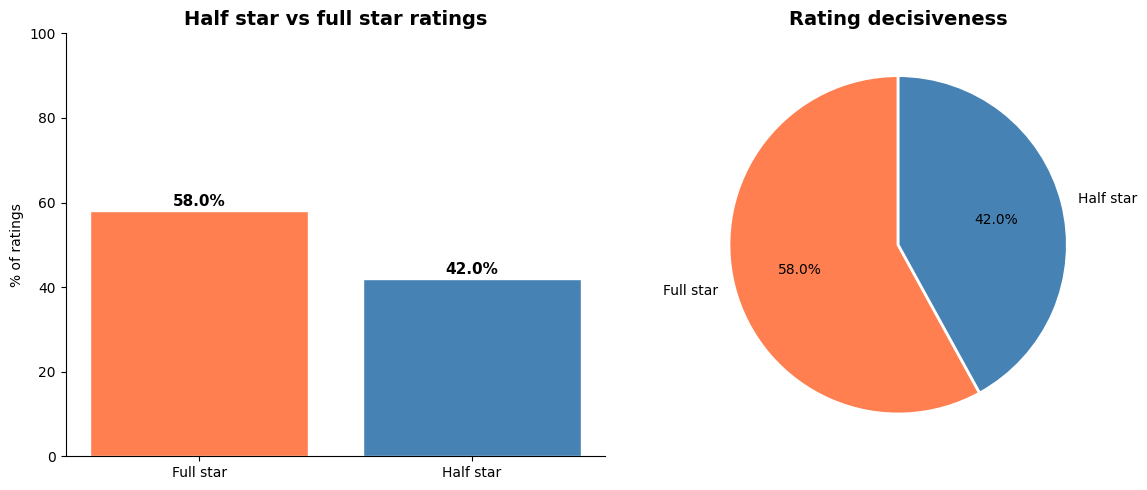

You use half stars 42.0% of the time — you're a nuanced rater!


In [118]:
ratings['is_half'] = ratings['rating'] % 1 != 0

half_full = ratings['is_half'].value_counts().rename({True: 'Half star', False: 'Full star'})
pct = (half_full / half_full.sum() * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
bars = ax[0].bar(pct.index, pct.values, color=['coral', 'steelblue'], edgecolor='white')
for bar, val in zip(bars, pct.values):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax[0].set_title('Half star vs full star ratings', fontsize=14, fontweight='bold')
ax[0].set_ylabel('% of ratings')
ax[0].set_ylim(0, 100)

# pie chart
ax[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
          colors=['coral', 'steelblue'], startangle=90,
          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax[1].set_title('Rating decisiveness', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"You use half stars {pct['Half star']}% of the time — ", end='')
print("you're a nuanced rater!" if pct['Half star'] > 40 else "you're a decisive rater!")

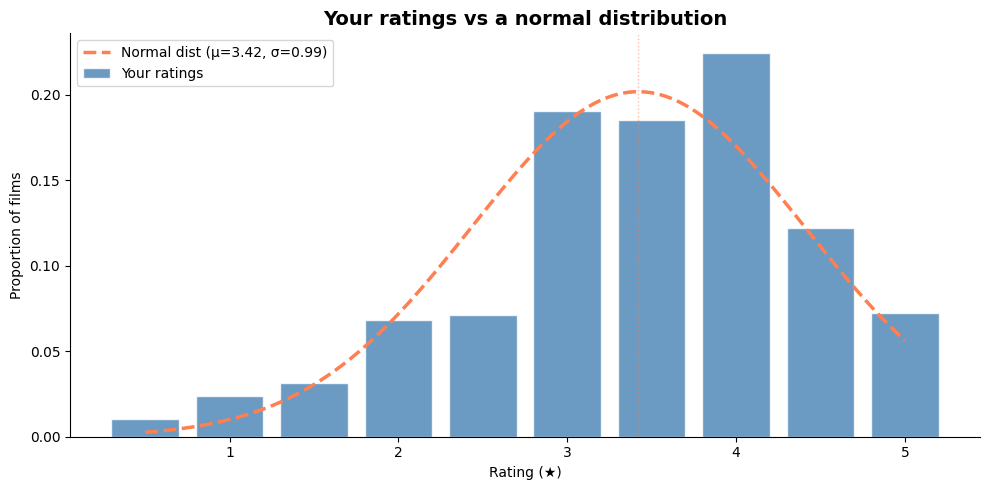

In [117]:
from scipy import stats
import numpy as np

rating_values = ratings['rating'].dropna()

fig, ax = plt.subplots()

# your actual ratings as a bar chart
rc = rating_values.value_counts(normalize=True).sort_index()
ax.bar(rc.index, rc.values, width=0.4, color='steelblue',
       edgecolor='white', alpha=0.8, label='Your ratings')

# normal distribution overlay
x = np.linspace(0.5, 5.0, 300)
mean, std = rating_values.mean(), rating_values.std()
normal_curve = stats.norm.pdf(x, mean, std) * 0.5  # scale to match bar width
ax.plot(x, normal_curve, color='coral', linewidth=2.5,
        linestyle='--', label=f'Normal dist (μ={mean:.2f}, σ={std:.2f})')

ax.axvline(mean, color='coral', linewidth=1, alpha=0.5, linestyle=':')
ax.set_title('Your ratings vs a normal distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating (★)')
ax.set_ylabel('Proportion of films')
ax.legend()
plt.tight_layout()
plt.show()

# Film taste

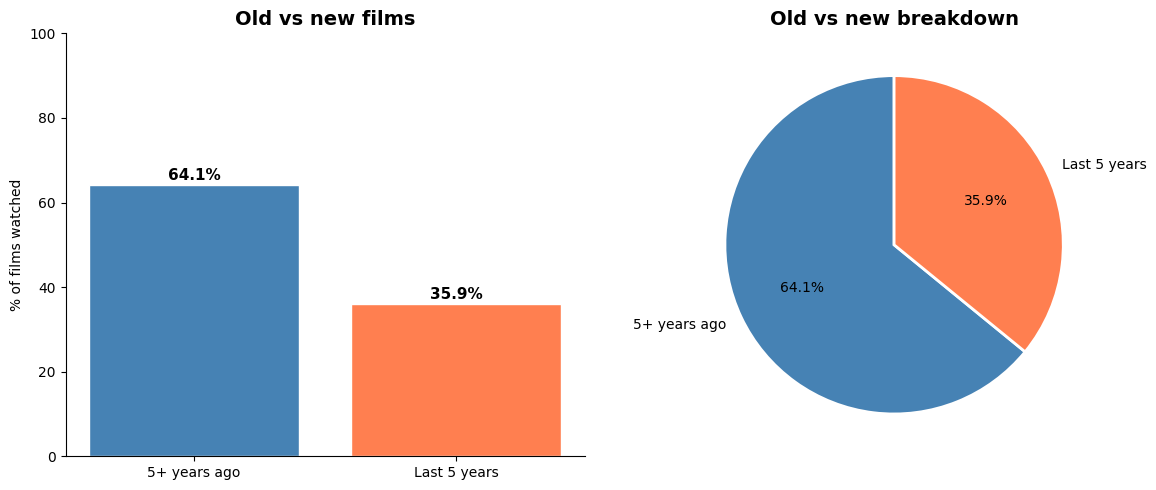

Avg rating by era:
era
5+ years ago    3.53
Last 5 years    3.22


In [116]:
current_year = 2026
ratings['era'] = ratings['year'].apply(
    lambda y: 'Last 5 years' if y >= current_year - 5 else '5+ years ago'
)

era_counts = ratings['era'].value_counts()
pct = (era_counts / era_counts.sum() * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# bar
bars = ax[0].bar(pct.index, pct.values,
                 color=['steelblue', 'coral'], edgecolor='white')
for bar, val in zip(bars, pct.values):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax[0].set_title('Old vs new films', fontsize=14, fontweight='bold')
ax[0].set_ylabel('% of films watched')
ax[0].set_ylim(0, 100)

# pie
ax[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
          colors=['steelblue', 'coral'], startangle=90,
          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax[1].set_title('Old vs new breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# avg rating comparison
era_ratings = ratings.groupby('era')['rating'].mean().round(2)
print('Avg rating by era:')
print(era_ratings.to_string())

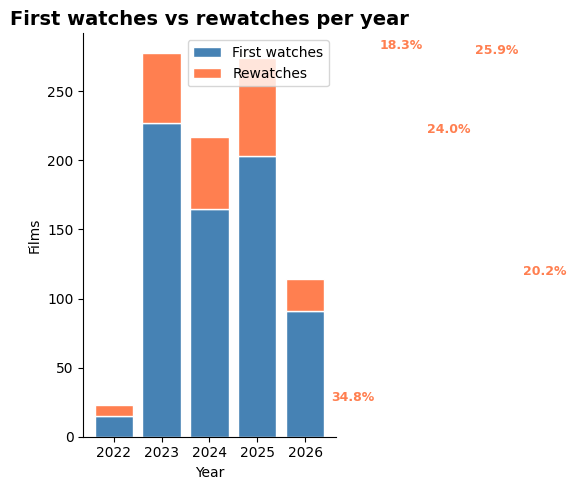

In [112]:
# flag rewatches — any film appearing more than once in diary
watch_counts = diary.groupby(['name', 'year'])['watched_date'].count().reset_index()
watch_counts.columns = ['name', 'year', 'watch_count']
diary_merged = diary_dated.merge(watch_counts, on=['name', 'year'], how='left')
diary_merged['is_rewatch'] = diary_merged['watch_count'] > 1

# group by calendar year
rewatch_by_year = (
    diary_merged.groupby(diary_merged['watched_date'].dt.year)
    .apply(lambda g: pd.Series({
        'rewatches': g['is_rewatch'].sum(),
        'first_watches': (~g['is_rewatch']).sum(),
        'total': len(g)
    }))
    .reset_index()
    .rename(columns={'watched_date': 'year'})
)
rewatch_by_year['rewatch_pct'] = (rewatch_by_year['rewatches'] / rewatch_by_year['total'] * 100).round(1)

fig, ax = plt.subplots()
ax.bar(rewatch_by_year['year'].astype(str), rewatch_by_year['first_watches'],
       label='First watches', color='steelblue', edgecolor='white')
ax.bar(rewatch_by_year['year'].astype(str), rewatch_by_year['rewatches'],
       bottom=rewatch_by_year['first_watches'],
       label='Rewatches', color='coral', edgecolor='white')

for _, row in rewatch_by_year.iterrows():
    ax.text(
        str(row['year']),
        row['total'] + 0.5,
        f"{row['rewatch_pct']}%",
        ha='center', va='bottom', fontsize=9, color='coral', fontweight='bold'
    )

ax.set_title('First watches vs rewatches per year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Films')
ax.legend()
plt.tight_layout()
plt.show()

# Watchlist Analysis

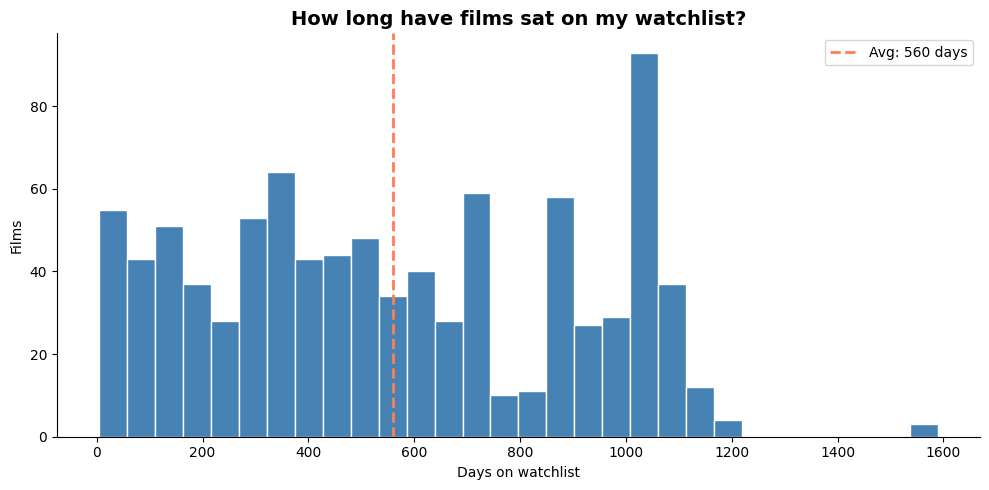

Oldest film on watchlist: 1590 days
Avg time on watchlist:    560 days
Films added this year:    138


In [113]:
today = pd.Timestamp.today()
watchlist['date'] = pd.to_datetime(watchlist['date'], errors='coerce')
watchlist['days_on_watchlist'] = (today - watchlist['date']).dt.days
watchlist['months_on_watchlist'] = (watchlist['days_on_watchlist'] / 30).astype(int)

fig, ax = plt.subplots()
ax.hist(watchlist['days_on_watchlist'].dropna(), bins=30,
        color='steelblue', edgecolor='white')

ax.axvline(watchlist['days_on_watchlist'].mean(), color='coral',
           linewidth=2, linestyle='--', label=f"Avg: {watchlist['days_on_watchlist'].mean():.0f} days")

ax.set_title('How long have films sat on my watchlist?', fontsize=14, fontweight='bold')
ax.set_xlabel('Days on watchlist')
ax.set_ylabel('Films')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Oldest film on watchlist: {watchlist['days_on_watchlist'].max():.0f} days")
print(f"Avg time on watchlist:    {watchlist['days_on_watchlist'].mean():.0f} days")
print(f"Films added this year:    {(watchlist['date'].dt.year == 2026).sum()}")

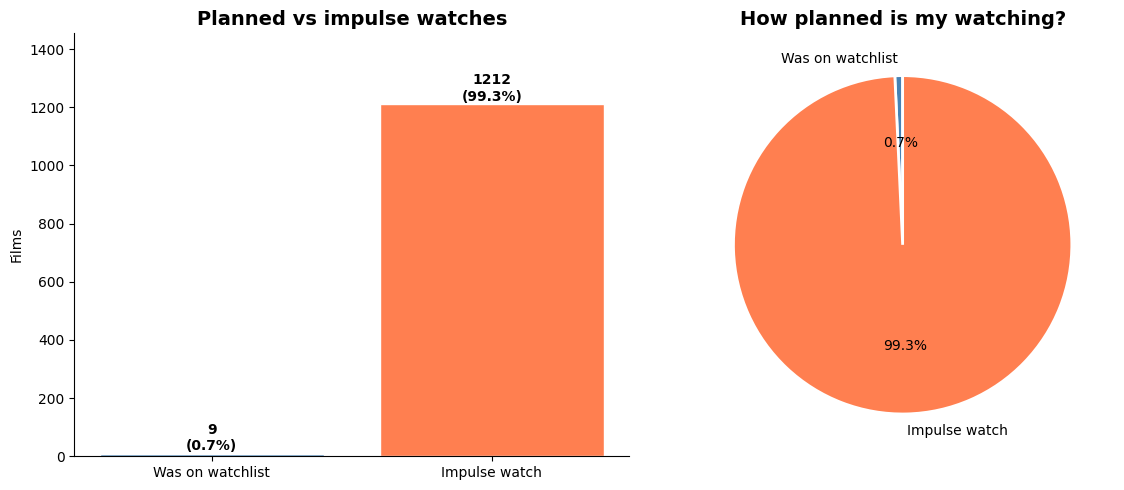

Total watched:       1221
Was on watchlist:    9 (0.7%)
Impulse watches:     1212 (99.3%)


In [114]:
watchlist_titles = set(watchlist['name'].str.lower().str.strip())
watched_titles   = set(watched['name'].str.lower().str.strip())

on_watchlist     = watched_titles & watchlist_titles
impulse_watches  = watched_titles - watchlist_titles

planned_pct = len(on_watchlist) / len(watched_titles) * 100
impulse_pct = len(impulse_watches) / len(watched_titles) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# bar
categories = ['Was on watchlist', 'Impulse watch']
values     = [len(on_watchlist), len(impulse_watches)]
bars = ax[0].bar(categories, values, color=['steelblue', 'coral'], edgecolor='white')
for bar, val, pct in zip(bars, values, [planned_pct, impulse_pct]):
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
ax[0].set_title('Planned vs impulse watches', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Films')
ax[0].set_ylim(0, max(values) * 1.2)

# pie
ax[1].pie([len(on_watchlist), len(impulse_watches)],
          labels=['Was on watchlist', 'Impulse watch'],
          autopct='%1.1f%%', colors=['steelblue', 'coral'],
          startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax[1].set_title('How planned is my watching?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total watched:       {len(watched_titles)}")
print(f"Was on watchlist:    {len(on_watchlist)} ({planned_pct:.1f}%)")
print(f"Impulse watches:     {len(impulse_watches)} ({impulse_pct:.1f}%)")

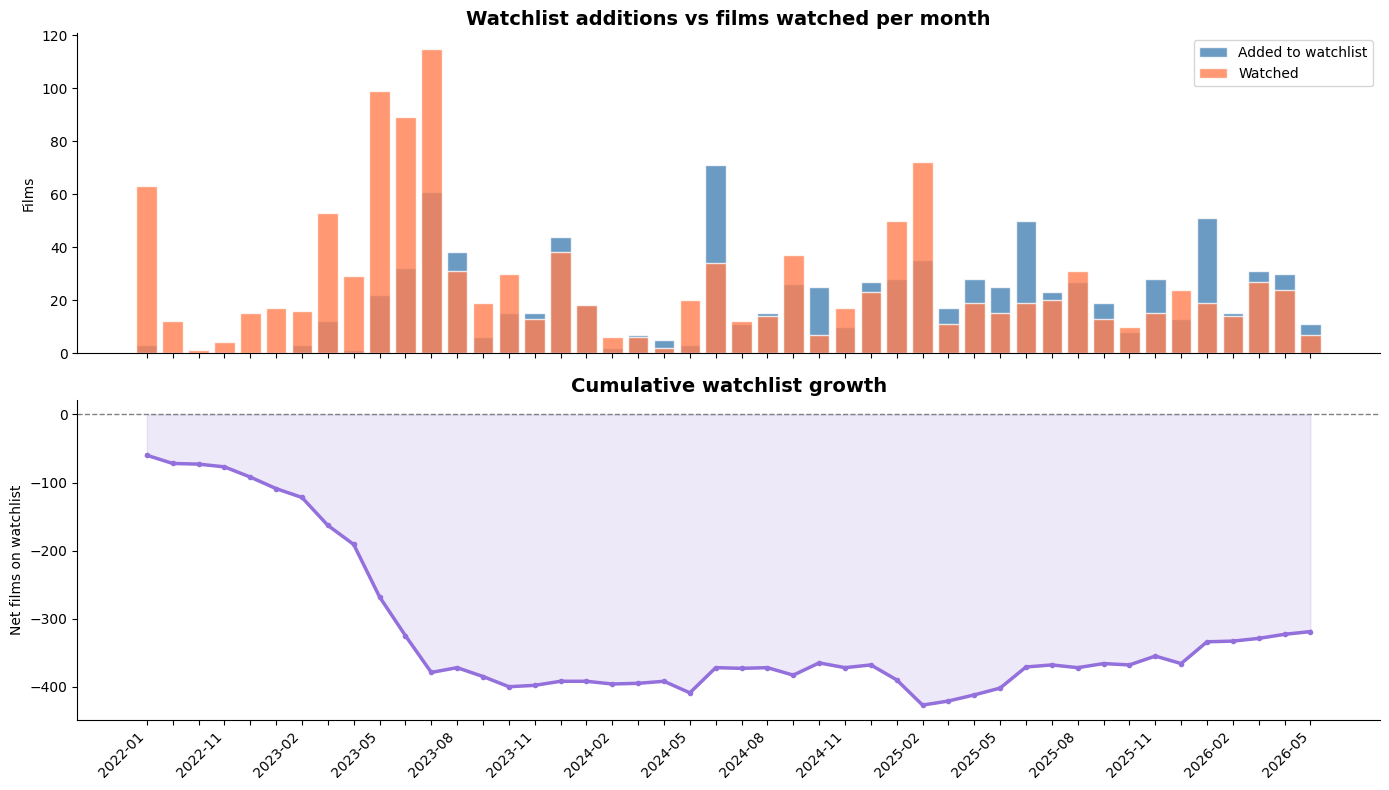

Current watchlist size: 911
Total watched:          1230
Net growth:             -319 films


In [115]:
watchlist['date'] = pd.to_datetime(watchlist['date'], errors='coerce')
watched['date']   = pd.to_datetime(watched['date'], errors='coerce')

# films added to watchlist per month
added = (
    watchlist.groupby(watchlist['date'].dt.to_period('M'))
    .size()
    .reset_index(name='added')
)
added['date'] = added['date'].astype(str)

# films watched per month
cleared = (
    watched.groupby(watched['date'].dt.to_period('M'))
    .size()
    .reset_index(name='watched')
)
cleared['date'] = cleared['date'].astype(str)

# merge
growth = added.merge(cleared, on='date', how='outer').fillna(0).sort_values('date')
growth['net'] = growth['added'] - growth['watched']
growth['cumulative'] = growth['net'].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# top — added vs watched per month
ax1.bar(growth['date'], growth['added'], label='Added to watchlist',
        color='steelblue', edgecolor='white', alpha=0.8)
ax1.bar(growth['date'], growth['watched'], label='Watched',
        color='coral', edgecolor='white', alpha=0.8)
ax1.set_title('Watchlist additions vs films watched per month', fontsize=14, fontweight='bold')
ax1.set_ylabel('Films')
ax1.legend()
for i, label in enumerate(ax1.get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

# bottom — cumulative growth
ax2.plot(growth['date'], growth['cumulative'],
         color='mediumpurple', linewidth=2.5, marker='o', markersize=3)
ax2.fill_between(range(len(growth)), growth['cumulative'], alpha=0.15, color='mediumpurple')
ax2.axhline(0, color='grey', linewidth=1, linestyle='--')
ax2.set_xticks(range(len(growth)))
ax2.set_xticklabels(growth['date'], rotation=45, ha='right')
ax2.set_title('Cumulative watchlist growth', fontsize=14, fontweight='bold')
ax2.set_ylabel('Net films on watchlist')
for i, label in enumerate(ax2.get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

print(f"Current watchlist size: {len(watchlist)}")
print(f"Total watched:          {len(watched)}")
print(f"Net growth:             {int(growth['net'].sum())} films")